# General Imports

In [2]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

### Setup Device for kaggle GPU
###### i don't have GPU on my device , so i'm training on kaggle

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

## Data Paths :

In [ ]:
## Kaggle Paths : 

# train : 
train_path = "/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip"

train_data = pd.read_csv(train_path , compression="zip")

# test : 
test_path = "/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip"

test_data = pd.read_csv(test_path , compression="zip")

# test_lables :
test_labels_path = "/kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip"

test_labels = pd.read_csv(test_labels_path , compression="zip")

In [ ]:
# local Paths :
train_path = "train.csv"
test_path = "test.csv"
test_labels_path = "test_labels.csv"

## Basic Info 

In [4]:
data = pd.read_csv(train_path)

classes = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

print(data.shape)

(159571, 8)


In [5]:
data.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [6]:
print(data[classes].sum())

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


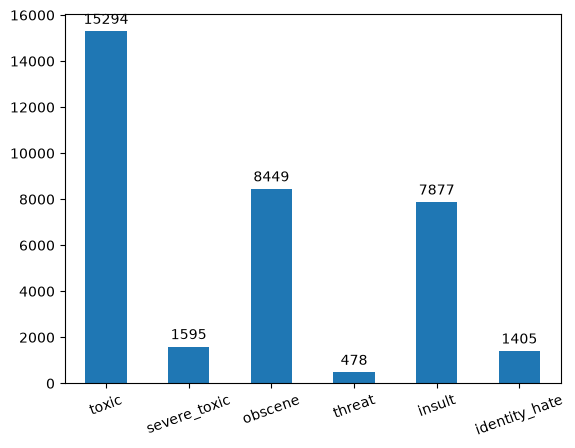

In [8]:
s = pd.Series({"toxic": 15294, "severe_toxic": 1595, "obscene": 8449, "threat": 478, "insult": 7877, "identity_hate": 1405})

ax = s.plot(kind="bar",  rot=20)
ax.bar_label(ax.containers[0], padding=3)

plt.show()

#### Drop 'id' & Rename 'comment' Column

In [7]:
data = data.drop(columns=['id'])
data.rename(columns={"comment_text":"comment"}, inplace=True)

In [8]:
data.head(25)

,comment,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,alignment on this subject and which are contra...,0,0,0,0,0,0


#### Check NULLS / Check Labels values / Check comments length

In [9]:
print("Missing comments:", data["comment"].isna().sum())

Missing comments: 0


In [10]:
# ensure there are not strange number , characters ,something like test data
for col in classes:
    print(col, data[col].unique())

toxic [0 1]
severe_toxic [0 1]
obscene [0 1]
threat [0 1]
insult [0 1]
identity_hate [0 1]


### Comments sentence length : 
#### 90%  ≤ 152 words
#### 95%  ≤ 230 words
#### 99%  ≤ 567 words
#### 99.5% ≤ 705 words
#### max = 1411 words

### Check Duplicates after apply normalization

In [11]:
def normalize_for_duplicate(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


data["duplicate_key"] = (
    data["comment"]
    .apply(normalize_for_duplicate)
)

duplicate_counts = data["duplicate_key"].value_counts()

duplicate_keys = duplicate_counts[
    duplicate_counts > 1
].index


before = len(data)

data = (
    data[
        ~data["duplicate_key"].isin(duplicate_keys)
    ]
    .reset_index(drop=True)
)

after = len(data)


print("Before:", before)
print("After:", after)
print("Removed:", before - after)


data = data.drop(columns=["duplicate_key"])

Before: 159571
After: 159078
Removed: 493


### Split labels from data ( X , Y)

In [ ]:
X_train = data['comment']

y_train = data.drop(columns=['comment'])

In [13]:
print("Labels columns : ",y_train.columns)

Labels columns :  Index(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')


## Process Comments : 
- Lower Case
- Replace URLS  , IPs , Punctuations and Symbols

In [14]:
import spacy


tokenizer_model = spacy.blank("en")


def process_comment(comment: str) -> list[str]:

    comment = comment.lower()

    # urls
    comment = re.sub(
        r"https?://\S+|www\.\S+",
        " URL ",
        comment
    )

    # IPs
    comment = re.sub(
        r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
        " IP ",
        comment
    )

    # punctuation , symbols
    comment = re.sub(
        r"[^A-Za-z0-9\s]",
        " ",
        comment
    )


    comment = tokenizer_model(comment)

    # tokens = [token.text for token in doc if not token.is_space and not token.is_stop]
    
    tokens = [ token.text for token in comment if not token.is_space]

    return tokens

#### Example of Output token : 

In [15]:
print(process_comment("\n\nCongratulations from me as well, use the https://facebook 192.168.1.1"))

['congratulations', 'from', 'me', 'as', 'well', 'use', 'the', 'URL', 'IP']


### Build Vocabs & ids

In [16]:
# build Vocab

def build_vocab(tokenized_comments : list[list[str]]) -> dict :
    
    vocab = {
        "<PAD>":0,
        "<UNK>":1
    }
    
    for tokens in tokenized_comments :
        for token in tokens :
            if token not in vocab : 
                vocab[token] = len(vocab)
    
    return vocab

#### Example on Vocabs output : 

In [17]:
# test building
build_vocab([
    ['this', 'is', 'a', 'comment'],
    ['another', 'comment'],
    ['you', 'are', 'stupid'],
])

{'<PAD>': 0,
 '<UNK>': 1,
 'this': 2,
 'is': 3,
 'a': 4,
 'comment': 5,
 'another': 6,
 'you': 7,
 'are': 8,
 'stupid': 9}

In [18]:
def tokens_to_ids(tokens, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

In [19]:
# make all sequence same length for data loaders ( batches )

def pad_or_truncate(ids, max_length, pad_id=0):
    
    if len(ids) > max_length:
        return ids[:max_length]

    return ids + [pad_id] * (max_length - len(ids))

## Prepare Comments Dataset :

In [20]:
from torch.utils.data import Dataset


class CommentsDataset(Dataset):
    
    
    def __init__(self , tokens , labels , vocab , max_length=40):
        
        self.__tokens = tokens
        self.__labels = labels
        self.__vocab = vocab
        self.__max_length = max_length
        
        
    def __len__(self):
        
        return len(self.__labels)
        
    
    def __getitem__(self, index):
        
        tokens = self.__tokens[index]
        
        ids = tokens_to_ids(tokens , self.__vocab)
        
        
        ids = pad_or_truncate(ids , self.__max_length)
        
        
        ids , label = torch.tensor(ids ,dtype=torch.long) , torch.tensor(self.__labels.iloc[index].values , dtype=torch.float32)
        
        
        return ids , label 

# used type long (integer) , because i will use embedding which will need input integer ids , that points to rows numbers : ( 1 -> vector 1 )

## Build LSTM Arch
- Bidirectional 

In [ ]:

class LSTM(nn.Module):
    
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=2,
        num_classes=6,
        dropout=0.3,
        bidirectional=False
    ):
        
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        direction = 2 if bidirectional else 1

        self.fc = nn.Linear(
            hidden_dim * direction,
            num_classes
        )

    def forward(self, x):
        
        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        if self.lstm.bidirectional:
            hidden = torch.cat(
                (hidden[-2], hidden[-1]),
                dim=1
            )
        else:
            hidden = hidden[-1]

        return self.fc(hidden)

#### Apply processing on training data :

In [22]:
trained_tokens = list(map(process_comment, X_train))

In [23]:
vocab = build_vocab(trained_tokens)

print(list(vocab.items())[:30])

len(vocab)

[('<PAD>', 0), ('<UNK>', 1), ('explanation', 2), ('why', 3), ('the', 4), ('edits', 5), ('made', 6), ('under', 7), ('my', 8), ('username', 9), ('hardcore', 10), ('metallica', 11), ('fan', 12), ('were', 13), ('reverted', 14), ('they', 15), ('weren', 16), ('t', 17), ('vandalisms', 18), ('just', 19), ('closure', 20), ('on', 21), ('some', 22), ('gas', 23), ('after', 24), ('i', 25), ('voted', 26), ('at', 27), ('new', 28), ('york', 29)]


172720

### Poition Weights
- trial to solve imbalance & oversampling , not so useful .

In [24]:
positive_counts = y_train[classes].sum()
negative_counts = len(y_train) - positive_counts

pos_weights = np.sqrt(
    negative_counts / positive_counts
)


pos_weight = torch.tensor(
    pos_weights.values,
    dtype=torch.float32
).to(device)

### Hyperparameters

In [72]:
pos_weight = torch.tensor( pos_weights.values, dtype=torch.float32 ).to(device)
embedding_size = 128
hidden_dim = 256
output_dim = 6
num_layers = 2
num_epochs = 10
max_length = 100
batch_size = 64
learning_rate = 0.0001
vocab_size = len(vocab)

## Data Loader & Optimizer

In [74]:
from torch.utils.data import DataLoader

train_dataset = CommentsDataset( trained_tokens , y_train ,vocab , max_length=max_length )

train_loader = DataLoader( train_dataset , shuffle=True , batch_size=batch_size )

In [ ]:
import torch.optim as optim


model = LSTM(
    vocab_size=vocab_size,
    embedding_dim=embedding_size,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=output_dim,
    bidirectional=True
)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # apply sigmoid enternly

optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

## Training Loop 

In [75]:
train_losses = []

for epoch in range(num_epochs):

    model.train()

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
    
        outputs = model(X_batch)
    
        loss = criterion(outputs, Y_batch)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_losses.append(loss.item())
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/10], Loss: 0.1093
Epoch [2/10], Loss: 0.1576
Epoch [3/10], Loss: 0.0873
Epoch [4/10], Loss: 0.0665
Epoch [5/10], Loss: 0.0508
Epoch [6/10], Loss: 0.0829
Epoch [7/10], Loss: 0.0794
Epoch [8/10], Loss: 0.0416
Epoch [9/10], Loss: 0.1352
Epoch [10/10], Loss: 0.0156


### Load Test Data 

In [ ]:
test_data = test_data.drop(columns=['id'])
test_data.rename(columns={"comment_text":"comment"}, inplace=True)


test_labels = test_labels.drop(columns=['id'])

test_labels.head(2)

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,-1,-1,-1,-1,-1,-1
1,-1,-1,-1,-1,-1,-1


#### Remove undefined rows from labels

In [30]:
valid = (test_labels[classes] != -1).all(axis=1)

test_data = test_data.loc[valid].reset_index(drop=True)
test_labels = test_labels.loc[valid].reset_index(drop=True)

In [31]:
print(test_data.shape)
print(test_labels.shape)

(63978, 1)
(63978, 6)


### Process test data

In [ ]:
test_tokens = []

for sentence in test_data['comment']:
    test_tokens.append(process_comment(sentence))


test_dataset = CommentsDataset( test_tokens, test_labels, vocab, max_length )

test_loader = DataLoader( test_dataset, batch_size=batch_size, shuffle=False )

## Validation Loop

In [90]:
model.eval()

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.9).float()

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            Y_batch.cpu().numpy()
        )

## Results & Visuals

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

### Classification Report

In [ ]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    zero_division=0
)

print(report)

               precision    recall  f1-score   support

        toxic       0.65      0.73      0.69      6090
 severe_toxic       0.37      0.39      0.38       367
      obscene       0.69      0.68      0.69      3691
       threat       0.36      0.58      0.45       211
       insult       0.69      0.56      0.62      3427
identity_hate       0.55      0.37      0.44       712

    micro avg       0.65      0.65      0.65     14498
    macro avg       0.55      0.55      0.54     14498
 weighted avg       0.65      0.65      0.65     14498
  samples avg       0.06      0.06      0.06     14498



## Training Loss Curve 

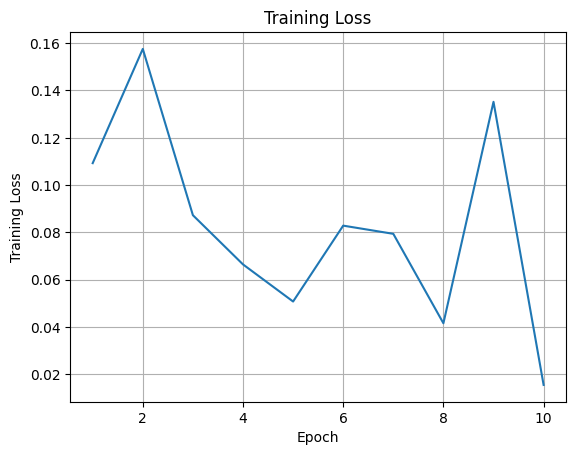

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

## Confusion Matrix 4 classes 

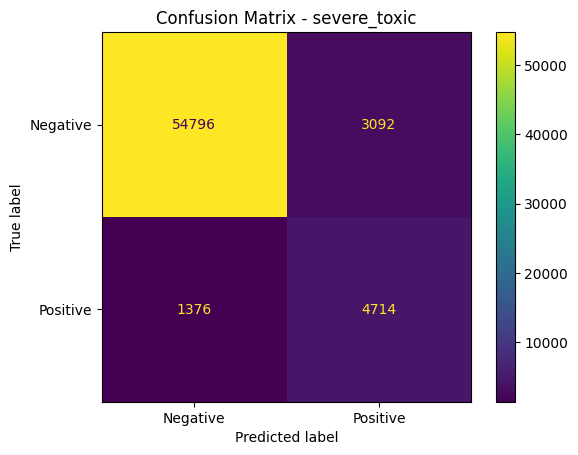

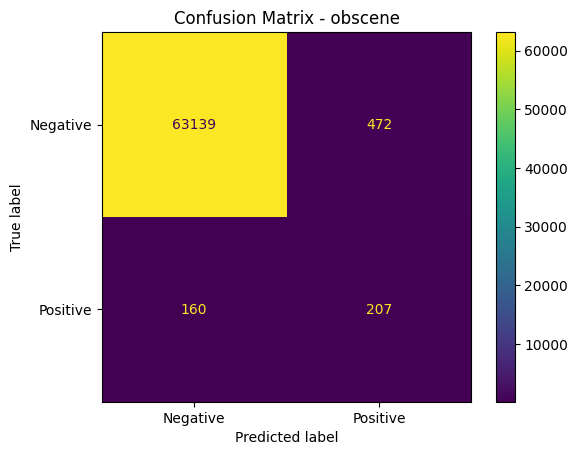

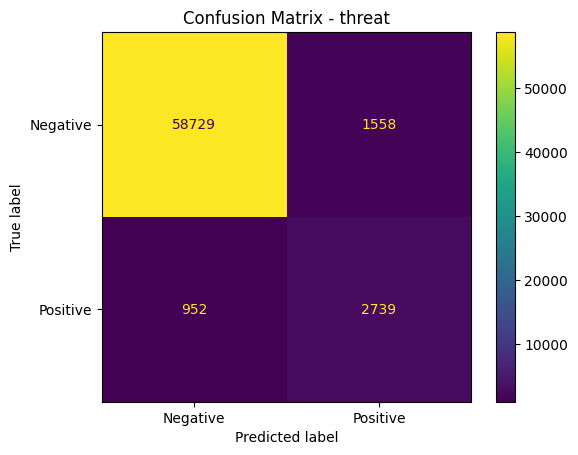

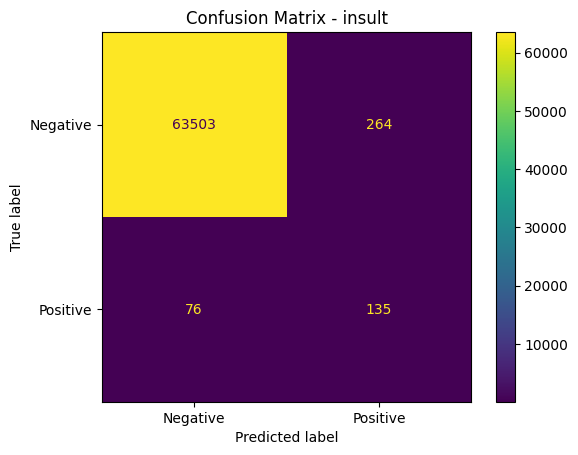

In [ ]:
labels = ["severe_toxic", "obscene", "threat", "insult"]

model.eval()
preds, true = [], []

with torch.no_grad():
    for x, y in test_loader:
        p = torch.sigmoid(model(x.to(device))) >= 0.85
        preds.append(p.cpu().numpy())
        true.append(y.numpy())

preds, true = np.vstack(preds), np.vstack(true)

for i, label in enumerate(labels):
    ConfusionMatrixDisplay.from_predictions(
        true[:, i], preds[:, i],
        display_labels=["Negative", "Positive"]
    )
    plt.title(f"Confusion Matrix - {label}")
    plt.show()